In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))
from src.data.data_loader import DataLoad
from src.portfolio.bl_optimization import BlackLitterman
from src.utils.metrics import *
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import colors as mcolors
np.random.seed(42)

In [2]:
# use one of the backtests to test out monte carlo sims
# monte carlo sims well be used to bootrap confidence intervals for certain metrics and distributions
# as well as see path dependence of portfolio backtest

In [3]:
dl = DataLoad()
backtest = dl.load_dataset("model")
backtest = backtest[backtest.index <= "2016-12-31"]
daily_stock_returns, monthly_stock_returns = dl.load_dataset("returns")
daily_stock_returns = daily_stock_returns[daily_stock_returns.index <= "2016-12-31"]
monthly_stock_returns = monthly_stock_returns[monthly_stock_returns.index <= "2016-12-31"]
backtest_months = backtest[backtest.index >= "2016-01-01"].index.unique()
first_month = backtest_months[0]
backtest_days = daily_stock_returns[daily_stock_returns.index > first_month].index.unique()
fama = dl.load_dataset("fama")
fama = fama[(fama.index >= "2016-02-01") & (fama.index <= "2016-12-31")]
rfr = fama["RF"]
snp = dl.load_dataset("GSPC")
snp = snp[(snp.index >= "2016-01-01") & (snp.index <= "2016-12-31")]

model.csv loaded succesfully
daily_stock_returns.csv loaded succesfully
monthly_stock_returns.csv loaded succesfully
fama.csv loaded succesfully
GSPC.csv loaded succesfully


In [4]:
dates = []
daily_returns = []
monthly_returns = []
daily_portfolio_values = []
monthly_portfolio_values = []
total_portfolio_value = 1.0
monthly_start_value = 1.0
first_day = backtest[backtest.index <= backtest_days[0]].index[-1]

for day in backtest_days:

    r = float(snp.loc[day].item())
    daily_returns.append(r)
    total_portfolio_value = total_portfolio_value * (1 + r)
    daily_portfolio_values.append(total_portfolio_value)

    if day in backtest_months:
        dates.append(day)
        monthly_return = (total_portfolio_value / monthly_start_value) - 1
        monthly_returns.append(monthly_return)
        monthly_portfolio_values.append(total_portfolio_value)
        monthly_start_value = total_portfolio_value

snp500_daily_returns = daily_returns
snp500_monthly_returns = monthly_returns
snp500_cagr = cagr(total_portfolio_value, len(monthly_returns) / 12)

In [5]:
dates = []
daily_returns = []
monthly_returns = []
daily_portfolio_values = []
monthly_portfolio_values = []
total_portfolio_value = 1
monthly_start_value = 1
first_day = backtest[backtest.index <= backtest_days[0]].index[-1]
model = LinearRegression(n_jobs=-1)
features = [c for c in backtest.columns if c not in ["Ticker", "Target"]]
model.fit(backtest[backtest.index < first_day][features].to_numpy(), backtest[backtest.index < first_day]["Target"].to_numpy())
bl = BlackLitterman()
preds = pd.DataFrame({"Ticker": backtest.loc[first_day]["Ticker"]})
pred = model.predict(backtest.loc[first_day][features].values)
preds["Predictions"] = pred
pred_z_scores = [pred]
true_z_scores = [backtest.loc[first_day]["Target"].to_numpy()]
weights, expected_returns = bl.optimize_portfolio(daily_stock_returns[daily_stock_returns.index <= first_day].tail(504), first_day, preds=preds)
positions = weights * total_portfolio_value
pred_returns = []
true_returns = []

for day in backtest_days:

    r = daily_stock_returns.loc[day].values 
    pnl = np.sum(positions * r)
    portfolio_return = pnl / total_portfolio_value
    daily_returns.append(portfolio_return)
    total_portfolio_value += pnl
    daily_portfolio_values.append(total_portfolio_value)
    positions = positions * (1 + r)
    weights = positions / total_portfolio_value

    if day in backtest_months:
        dates.append(day)
        monthly_return = (total_portfolio_value / monthly_start_value) - 1
        monthly_returns.append(monthly_return)
        monthly_portfolio_values.append(total_portfolio_value)
        monthly_start_value = total_portfolio_value
        pred_returns.append(expected_returns)
        true_returns.append(monthly_stock_returns.loc[day].values)
        model.fit(backtest[backtest.index < day][features].to_numpy(), backtest[backtest.index < day]["Target"].to_numpy())
        pred = model.predict(backtest.loc[day][features].values)
        preds["Predictions"] = pred
        weights, expected_returns = bl.optimize_portfolio(daily_stock_returns[daily_stock_returns.index <= day].tail(504), day, preds=preds, y_pred=pred_z_scores, y_true=true_z_scores)
        positions = weights * total_portfolio_value
        pred_z_scores.append(pred)
        true_z_scores.append(backtest.loc[day]["Target"].to_numpy())


daily_res = pd.DataFrame({"Portfolio Growth" : daily_portfolio_values, "Returns" : daily_returns}, index=backtest_days)



In [6]:
# now that we have backtest, we do monte carlo sim
# we will be using stationary bootstrap

In [7]:
# new metrics we will be need

def calculate_final_portfolio(monthly_returns):
    final_value = 1 * np.prod(1 + monthly_returns)

    return final_value

def calculate_daily_portfolio_values(monthly_returns):
    daily_portfolio_values = np.cumprod(1 + monthly_returns)

    return daily_portfolio_values

def total_return_stats(total_return_values):

    return np.mean(total_return_values), np.median(total_return_values)

def total_return_quantiles(total_return_values):
    total_return_values = np.array(total_return_values)

    min_return = np.min(total_return_values)
    stress = np.quantile(total_return_values, 0.005)
    bad = np.quantile(total_return_values, 0.05)
    typical = np.quantile(total_return_values, 0.5)
    good = np.quantile(total_return_values, 0.95)
    upside = np.quantile(total_return_values, 0.995)
    max_return = np.max(total_return_values)

    return min_return, stress, bad, typical, good, upside, max_return

def mean_port_volatility(portfolio_volatility_values):

    return np.mean(portfolio_volatility_values)

def mean_ulcer_index(ulcer_index_values):

    return np.mean(ulcer_index_values)

def mean_avg_dd_duration(avg_dd_duration_values):

    return np.mean(avg_dd_duration_values)

def prob_cagr_over_null(cagr_values):
    cagr_values = np.array(cagr_values)

    return len(cagr_values[cagr_values > 0]) / len(cagr_values)

def prob_cagr_over_benchmark(cagr_values, benchmark_cagr_value):
    cagr_values = np.array(cagr_values)

    return len(cagr_values[cagr_values > benchmark_cagr_value]) / len(cagr_values)

def prob_sharpe_over_1(sharpe_values):
    sharpe_values = np.array(sharpe_values)

    return len(sharpe_values[sharpe_values > 1]) / len(sharpe_values)

def prob_max_dd_over(max_dd_values, threshold):
    max_dd_values = np.array(max_dd_values)

    return len(max_dd_values[max_dd_values < threshold]) / len(max_dd_values)

def prob_avg_dd_duration_over_365(avg_dd_duration_values):
    avg_dd_duration_values = np.array(avg_dd_duration_values)

    return len(avg_dd_duration_values[avg_dd_duration_values > 365]) / len(avg_dd_duration_values)

def prob_negative_return(final_portfolio_values):
    final_portfolio_values = np.array(final_portfolio_values)

    return len(final_portfolio_values[final_portfolio_values < 1]) / len(final_portfolio_values)

def prob_loss_over(final_portfolio_values, threshold):
    final_portfolio_values = np.array(final_portfolio_values)
    loss = 1 - final_portfolio_values

    return len(loss[loss > threshold]) / len(loss)



In [8]:
# we will use 10000 samples to lower error in confidence intervals as much as possible
# with 10000 SE is about 0.22%

In [9]:
# create moving 3 month blocks
df = daily_res.copy()
r = df["Returns"].to_numpy()
n = len(r)
L = 21
p = 1 / L

In [10]:
final_portfolio_values = np.empty((10000))
total_return_values = np.empty((10000))
portfolio_volatility_values = np.empty((10000))
sharpe_ratio_values = np.empty((10000))
max_dd_values = np.empty((10000))
average_dd_duration_values = np.empty((10000))
ulcer_index_values = np.empty((10000))
cvar_values = np.empty((10000))
cagr_values = np.empty((10000))
daily_portfolios_values = np.empty((10000, n))

for i in range(10000):
    sample = np.empty(n)
    j = np.random.randint(n)

    for t in range(n):
        if np.random.rand() < p:
            j = np.random.randint(n)
        sample[t] = r[j]
        j = (j + 1) % n

    daily_returns = sample
    final_portfolio_value = calculate_final_portfolio(daily_returns)
    final_portfolio_values[i] = final_portfolio_value
    total_return_values[i] = final_portfolio_value - 1
    daily_portfolio_values = calculate_daily_portfolio_values(daily_returns)
    daily_portfolios_values[i] = daily_portfolio_values
    daily_res = pd.DataFrame({"Returns" : daily_returns}, index=df.index)
    monthly_res = (1 + daily_res["Returns"]).resample("ME").prod() - 1
    monthly_returns = monthly_res.to_numpy()
    portfolio_volatility_value = portfolio_volatility(monthly_returns)
    portfolio_volatility_values[i] = portfolio_volatility_value
    sharpe_ratio_value = sharpe_ratio(monthly_returns, rfr)
    sharpe_ratio_values[i] = sharpe_ratio_value
    dds = drawdowns(daily_portfolio_values)
    max_dd = max_drawdown(dds)
    max_dd_values[i] = max_dd
    average_dd_duration = average_drawdown_duration(daily_portfolio_values)
    average_dd_duration_values[i] = average_dd_duration
    ulcer_index_value = ulcer_index(dds)
    ulcer_index_values[i] = ulcer_index_value
    cvar_value = cvar(monthly_returns)
    cvar_values[i] = cvar_value
    cagr_value = cagr(final_portfolio_value, len(monthly_returns)/12)
    cagr_values[i] = cagr_value
    


total_return_mean, total_return_median = total_return_stats(total_return_values)
min_return, stress, bad, typical, good, upside, max_return = total_return_quantiles(total_return_values)
mean_volatility = mean_port_volatility(portfolio_volatility_values)
mean_ulcer_index_value = mean_ulcer_index(ulcer_index_values)
mean_avg_dd_duration_value = mean_avg_dd_duration(average_dd_duration_values)
prob_cagr_over_null_value = prob_cagr_over_null(cagr_values)
prob_cagr_over_benchmark_value = prob_cagr_over_benchmark(cagr_values, snp500_cagr)
prob_sharpe_over_1_value = prob_sharpe_over_1(sharpe_ratio_values)
prob_max_dd_over_20 = prob_max_dd_over(max_dd_values, -0.2)
prob_max_dd_over_50 = prob_max_dd_over(max_dd_values, -0.5)
prob_avg_dd_duration_over_365_value = prob_avg_dd_duration_over_365(average_dd_duration_values)
prob_negative_return_value = prob_negative_return(final_portfolio_values)
prob_loss_over_20 = prob_loss_over(final_portfolio_values, 0.2)
prob_loss_over_50 = prob_loss_over(final_portfolio_values, 0.5)

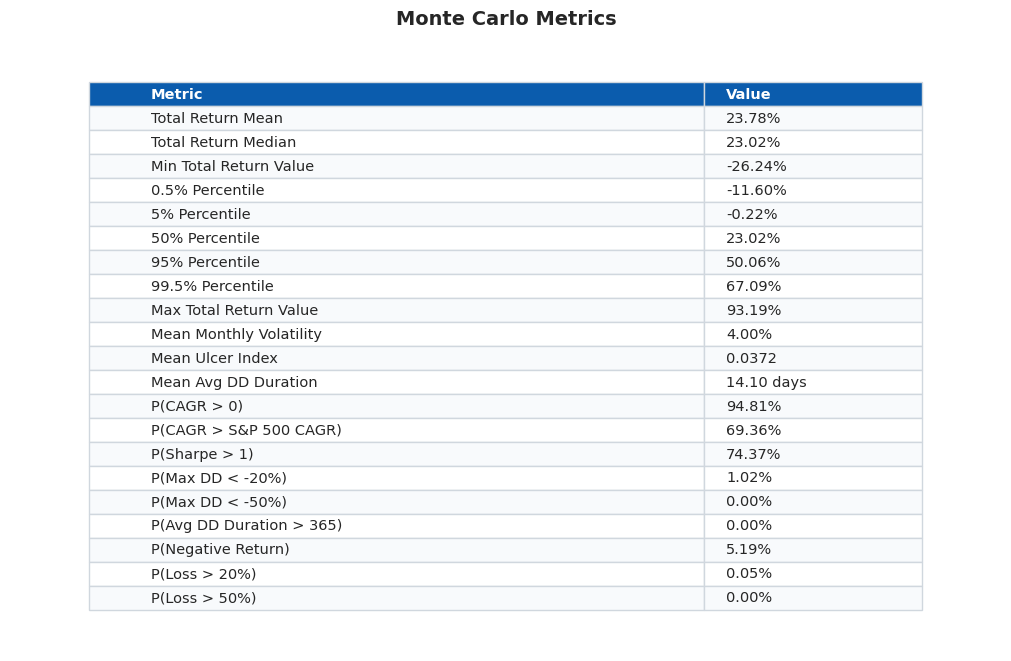

In [11]:
plt.style.use("seaborn-v0_8-whitegrid")

summary_metrics = pd.DataFrame(
    [
        ("Total Return Mean", f"{total_return_mean:.2%}"),
        ("Total Return Median", f"{total_return_median:.2%}"),
        ("Min Total Return Value", f"{min_return:.2%}"),
        ("0.5% Percentile", f"{stress:.2%}"),
        ("5% Percentile", f"{bad:.2%}"),
        ("50% Percentile", f"{typical:.2%}"),
        ("95% Percentile", f"{good:.2%}"),
        ("99.5% Percentile", f"{upside:.2%}"),
        ("Max Total Return Value", f"{max_return:.2%}"),
        ("Mean Monthly Volatility", f"{mean_volatility:.2%}"),
        ("Mean Ulcer Index", f"{mean_ulcer_index_value:.4f}"),
        ("Mean Avg DD Duration", f"{mean_avg_dd_duration_value:.2f} days"),
        ("P(CAGR > 0)", f"{prob_cagr_over_null_value:.2%}"),
        ("P(CAGR > S&P 500 CAGR)", f"{prob_cagr_over_benchmark_value:.2%}"),
        ("P(Sharpe > 1)", f"{prob_sharpe_over_1_value:.2%}"),
        ("P(Max DD < -20%)", f"{prob_max_dd_over_20:.2%}"),
        ("P(Max DD < -50%)", f"{prob_max_dd_over_50:.2%}"),
        ("P(Avg DD Duration > 365)", f"{prob_avg_dd_duration_over_365_value:.2%}"),
        ("P(Negative Return)", f"{prob_negative_return_value:.2%}"),
        ("P(Loss > 20%)", f"{prob_loss_over_20:.2%}"),
        ("P(Loss > 50%)", f"{prob_loss_over_50:.2%}"),
    ],
    columns=["Metric", "Value"],
)

fig_table, ax_table = plt.subplots(figsize=(10, 6.5), constrained_layout=True)
ax_table.axis("off")
table = ax_table.table(
    cellText=summary_metrics.values,
    colLabels=summary_metrics.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.62, 0.22],
)
table.auto_set_font_size(False)
table.set_fontsize(10.5)
table.scale(1, 1.18)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D7DE")
    if row == 0:
        cell.set_facecolor("#0B5CAD")
        cell.set_text_props(color="white", weight="bold")
    elif row % 2 == 1:
        cell.set_facecolor("#F8FAFC")
    else:
        cell.set_facecolor("white")

ax_table.set_title("Monte Carlo Metrics", fontsize=14, fontweight="bold", pad=12)
plt.show()

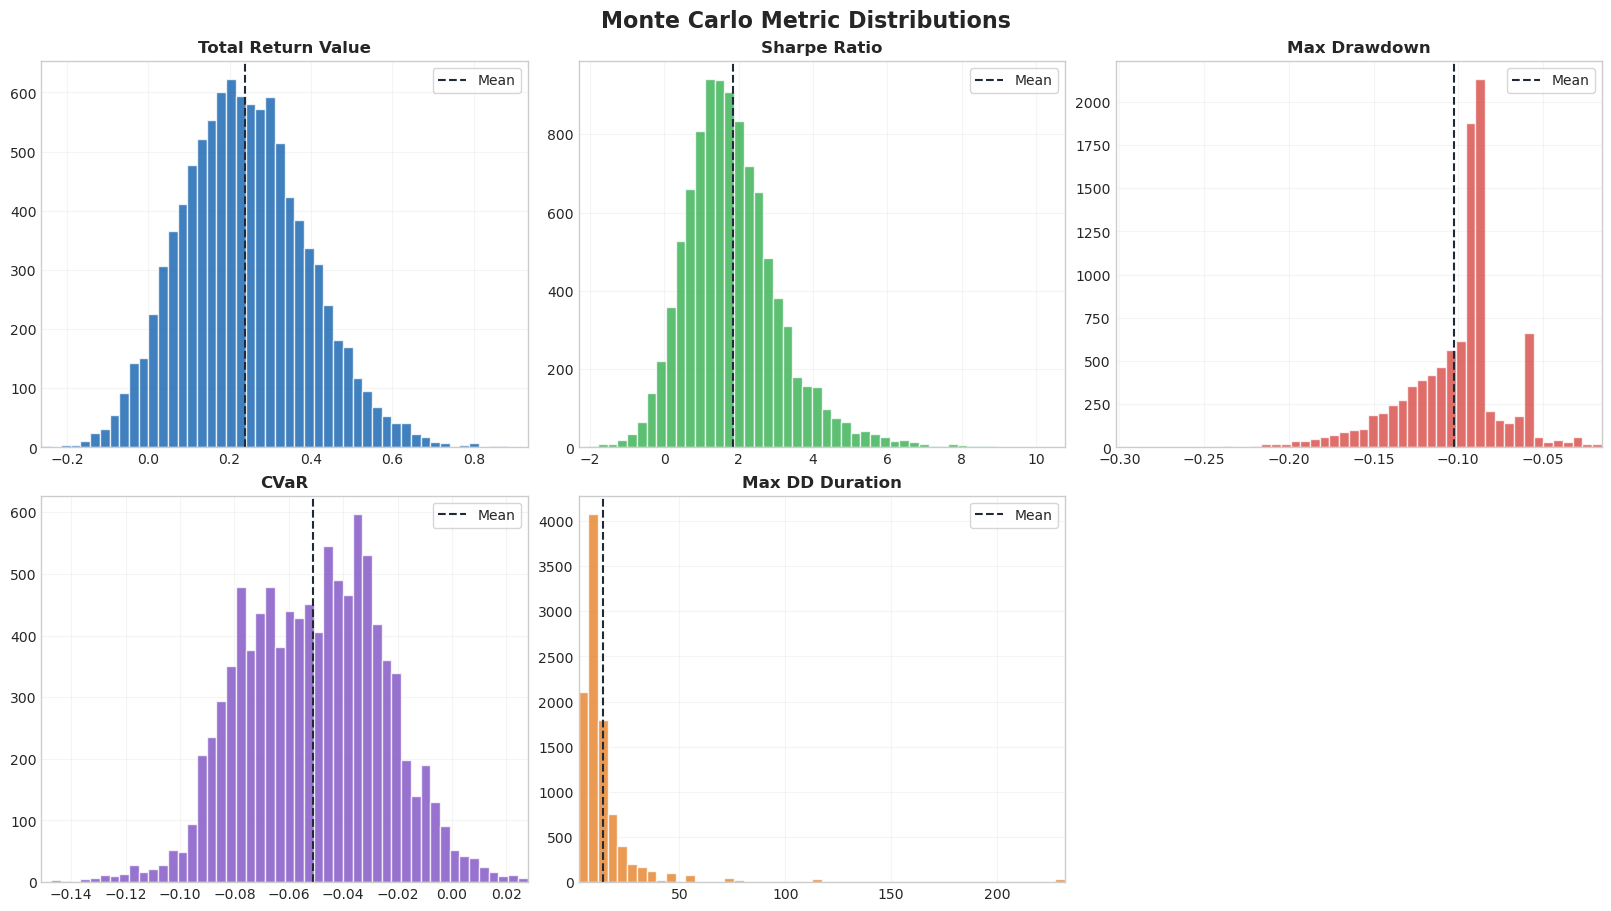

In [12]:

histogram_data = [
    ("Total Return Value", total_return_values, "#0B5CAD"),
    ("Sharpe Ratio", sharpe_ratio_values, "#2EAD4A"),
    ("Max Drawdown", max_dd_values, "#D64541"),
    ("CVaR", cvar_values, "#7A4CC2"),
    ("Max DD Duration", average_dd_duration_values, "#E67E22"),
]

fig_hist, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
axes = axes.ravel()

for index, (title, values, color) in enumerate(histogram_data):
    ax = axes[index]
    vals = np.array(values)
    ax.hist(vals, bins=50, color=color, alpha=0.78, edgecolor="white")
    ax.axvline(np.mean(vals), color="#1F2937", linestyle="--", linewidth=1.5, label="Mean")
    ax.set_title(title, fontweight="bold")
    ax.set_xlim(vals.min(), vals.max())

    ax.grid(True, alpha=0.2)
    ax.legend(frameon=True)

axes[-1].axis("off")
fig_hist.suptitle("Monte Carlo Metric Distributions", fontsize=16, fontweight="bold")
plt.show()


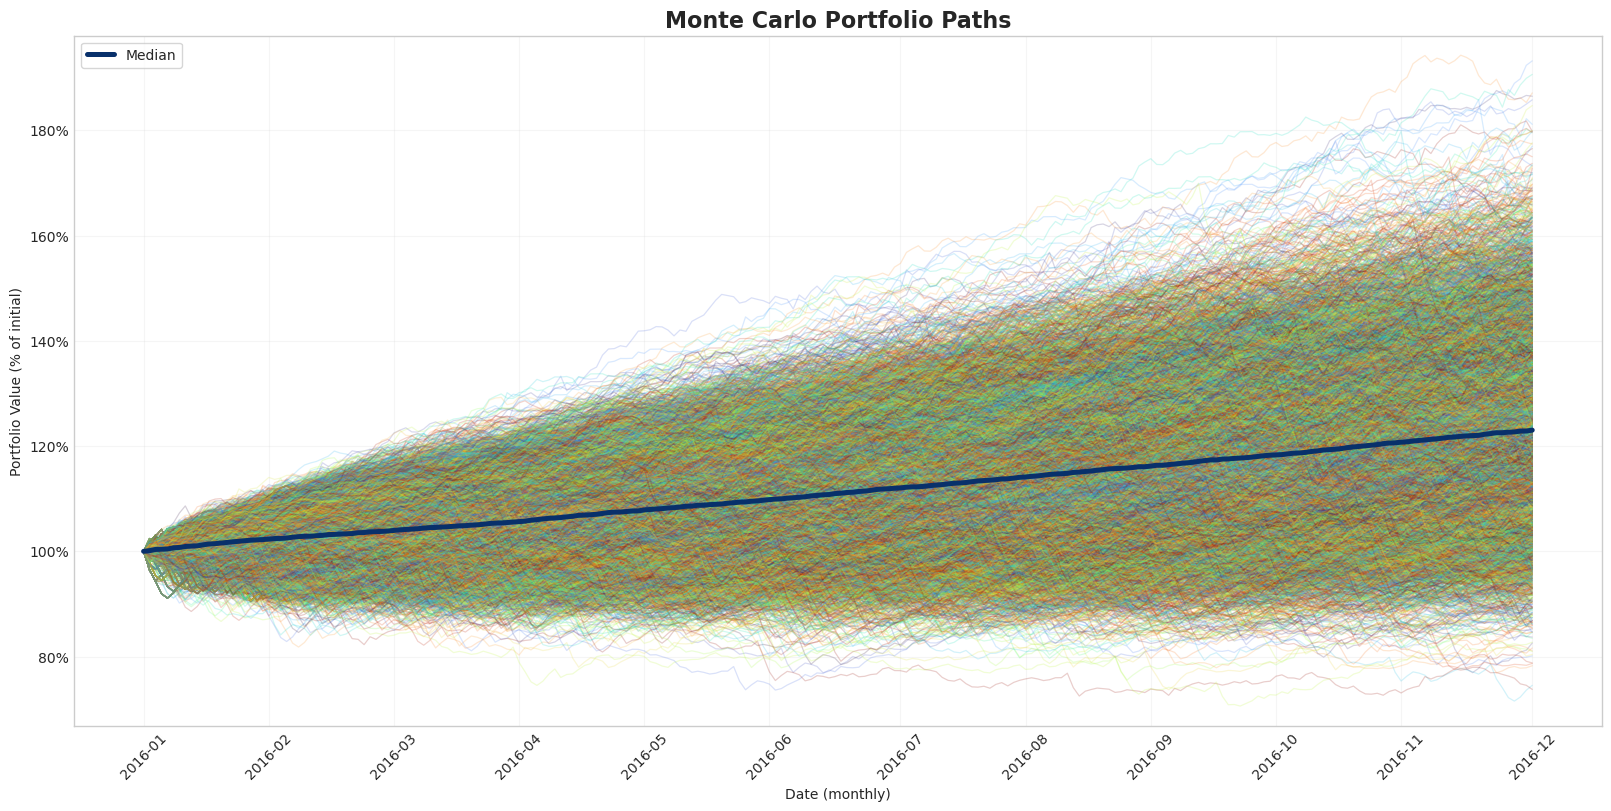

In [13]:
portfolio_paths = daily_portfolios_values
portfolio_paths = np.concatenate([np.ones((portfolio_paths.shape[0], 1)), portfolio_paths], axis=1)
portfolio_paths_pct = portfolio_paths * 100
portfolio_paths_pct[:, 0] = 100

fig_paths, ax_paths = plt.subplots(figsize=(16, 8), constrained_layout=True)
x = np.arange(portfolio_paths_pct.shape[1])

n_paths = portfolio_paths_pct.shape[0]
base = plt.cm.turbo(np.linspace(0, 1, n_paths))
np.random.shuffle(base)
path_colors = [mcolors.to_hex(c) for c in base]

for idx, path in enumerate(portfolio_paths_pct):
    ax_paths.plot(x, path, color=path_colors[idx], alpha=0.2, linewidth=0.9, zorder=1)

median_path = np.median(portfolio_paths_pct, axis=0)
ax_paths.plot(x, median_path, color="#08306B", linewidth=3.6, label="Median", zorder=3)

monthly_labels = [d.strftime("%Y-%m") for d in backtest_months]
monthly_positions = np.linspace(0, portfolio_paths_pct.shape[1]-1, num=len(monthly_labels), dtype=int)
if len(monthly_labels) > 12:
    step = int(np.ceil(len(monthly_labels)/12))
    monthly_labels = monthly_labels[::step]
    monthly_positions = monthly_positions[::step]

ax_paths.set_xticks(monthly_positions)
ax_paths.set_xticklabels(monthly_labels, rotation=45)

ax_paths.set_title("Monte Carlo Portfolio Paths", fontsize=16, fontweight="bold")
ax_paths.set_xlabel("Date (monthly)")
ax_paths.set_ylabel("Portfolio Value (% of initial)")
ax_paths.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
all_min = portfolio_paths_pct.min()
all_max = portfolio_paths_pct.max()
pad = max(1.0, (all_max - all_min) * 0.03)
ax_paths.set_ylim(bottom=all_min - pad, top=all_max + pad)
ax_paths.grid(True, alpha=0.18)
ax_paths.legend(frameon=True)
plt.show()
